# Prototype: Run outbreak dynamics model

A prototype test of the consolidated outbreak dynamics model

In [1]:

import os
import importlib
from copy import deepcopy
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd

import inframind_proteus.outbreak_dynamics
from inframind_proteus.outbreak_dynamics.sampling import sample_lhs

importlib.reload(inframind_proteus.outbreak_dynamics)
from inframind_proteus.outbreak_dynamics import (
    SimulationConfig, RenewalSimulator, SimulationOutput,
    LogisticRT, ConstantGammaGT, build_calibration_params_df,
    build_initial_infec_df
)

from inframind_proteus.outbreak_dynamics.utils import (
    load_yaml_dict, epiweek_to_date
)


## Run simulations for one location and season

In [2]:
# =================
# SPECIFIC PARAMETERS

uf = "SP" #  "SE" # "PI" # "SP"
season = 2022
epiweeek_sim_start = 41 - 8   # Mosqlimate: Starts at 41. Add more for TG and warm-up.
epiweek_sim_end = 45

num_simulations = int(2**12)

# =================

# --- General UF-level demographic data
uf_table_df = pd.read_csv(Path("../../data/demographic/uf_table.csv"))
population_size = uf_table_df.set_index("uf").loc[uf, f"population_{season}"].item()  # Take the population at the start of the season for reference.


# --- Observation data
observations_sr = (
    pd.read_csv(
        f"../../data/disease/dengue_cases_uf_weekly/dengue_{uf}.csv",
        parse_dates=["date"],
    )
    .set_index("date")["value"]
)

# --- Simulation setup
config_dict = load_yaml_dict(Path("../../configs/prototype_run_dynamic_model.yaml"))
# config_dict = load_yaml_dict(Path("../../configs/outbreak_dynamics_example.yaml"))
simulator = RenewalSimulator.from_config_dict(config_dict)

# Override desired configurations
config = simulator.config
config.mode = "calibration"
config.num_simulations = num_simulations
config.population_size = population_size

# Simulation and calibration time ranges
config.temporal.sim_start = _sim_start = epiweek_to_date(100 * season + epiweeek_sim_start)
_sim_end = epiweek_to_date(100 * (season + 1) + epiweek_sim_end)
config.num_time_steps = int(np.ceil((_sim_end - _sim_start).days / 7))
config.temporal.calibration_start = epiweek_to_date(100 * season + 41)  # Mosqlimate instructions
config.temporal.calibration_end = epiweek_to_date(100 * (season + 1) + 40)  # Mosqlimate instructions
config.temporal.zero_date = config.temporal.calibration_start



# --- Build auxiliary data frames for simulations
params_df = build_calibration_params_df(config.num_simulations, config.sampling)
config.num_simulations = num_simulations = params_df.shape[0]  # Update in case sampling method changes number of simulations
# params_df.index.name = "i_simulation"
initial_infec_df = build_initial_infec_df(
    config.num_simulations, simulator._gt_max_steps, config.temporal.step_dt,
    config.initial_infections
)

# --- Run simulations (calibration mode)
print(f"Running {config.num_simulations} simulations...")
results = simulator.run(
    params_df=params_df,
    initial_infec_df=initial_infec_df,
    observations_sr=observations_sr,
)
print("done!")


Running 4096 simulations...
done!


In [3]:
results2 = simulator.run(
    params_df=params_df,
    initial_infec_df=initial_infec_df,
    observations_sr=observations_sr,
)

SimulationOutput.concat(
    [results, results2],
)

SimulationOutput(infec_df=t             2022-08-14  2022-08-21  2022-08-28  2022-09-04  2022-09-11  \
i_simulation                                                               
0                0.99995     0.99995    0.999938    0.999914     0.99990   
1                0.99995     0.99995    0.999938    0.999914     0.99990   
2                0.99995     0.99995    0.999938    0.999914     0.99990   
3                0.99995     0.99995    0.999938    0.999914     0.99990   
4                0.99995     0.99995    0.999938    0.999914     0.99990   
...                  ...         ...         ...         ...         ...   
4091             0.99995     0.99995    0.999938    0.999914     0.99990   
4092             0.99995     0.99995    0.999938    0.999914     0.99990   
4093             0.99995     0.99995    0.999938    0.999914     0.99991   
4094             0.99995     0.99995    0.999938    0.999914     0.99990   
4095             0.99995     0.99995    0.999938    0.999914  

## Visualizations

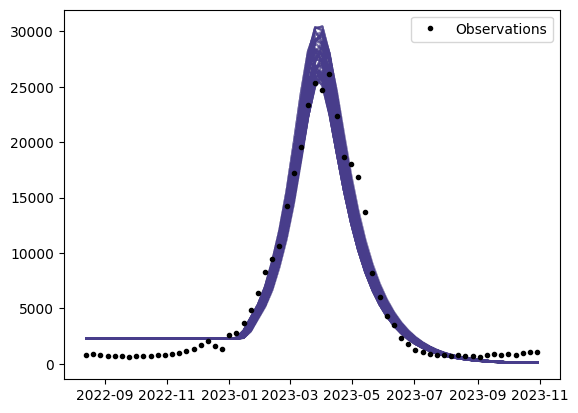

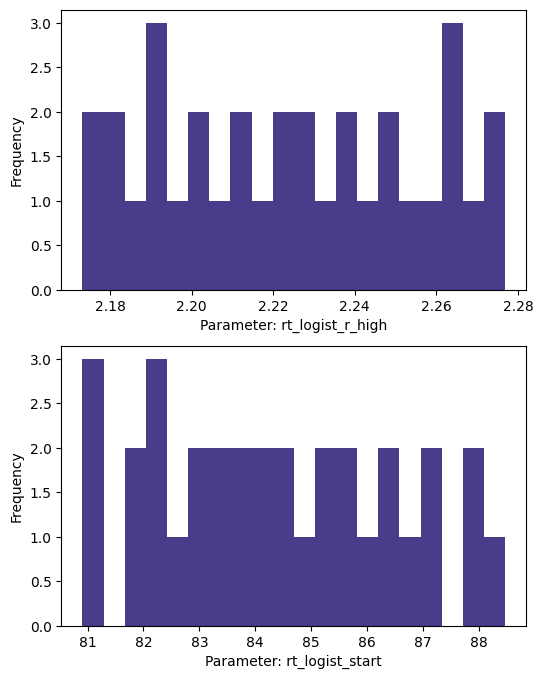

Average over selected parameter distributions: 
rt_logist_r_high     2.223650
rt_logist_start     84.384072
dtype: float64


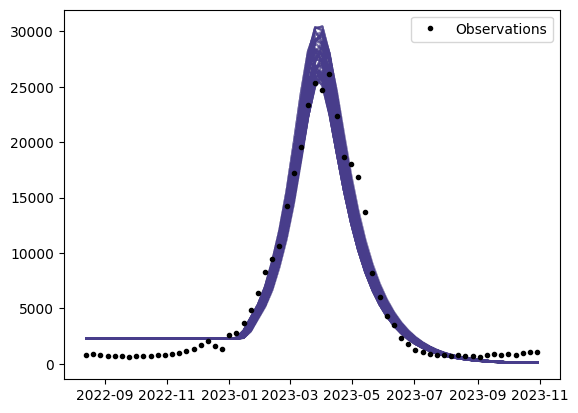

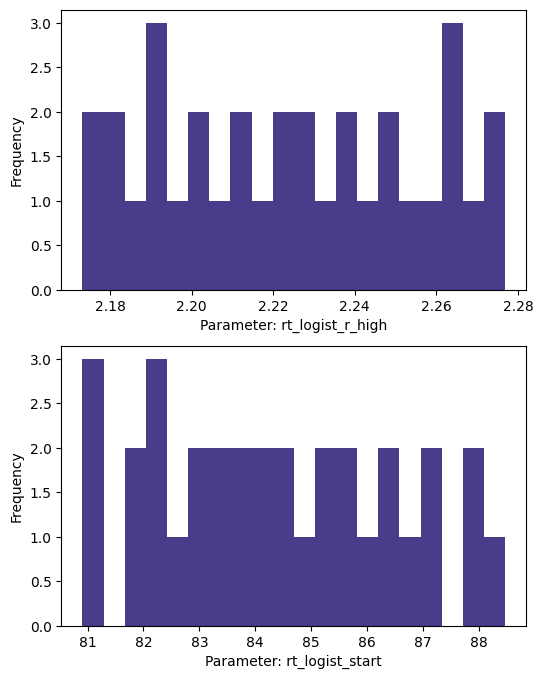

In [3]:
# --- Summary WIS statistics
wis_sr = pd.Series(
    results.scoring.wis_array.sum(axis=1),
)
wis_sr.index.name = "i_simulation"
wis_sr.name = "total_wis"
# wis_df.columns =

# ----
# Test methods to select best simulations
# ======================================

# --- Simple n-best
# # -()- By number
# _n = min(200, wis_sr.shape[0])

# -()- By fraction of number of simulations
_nsim = wis_sr.shape[0]
_frac = 0.001
_n = np.ceil(_frac * _nsim).astype(int)

selected_wis_sr = wis_sr.nsmallest(_n)

best_median_case_trajectories_df = results.case_beam_df.xs(0.5, level="quantile").loc[selected_wis_sr.index]

# -()- Optional: Random sample to reduce plot load
nsample = 500
df: pd.DataFrame = best_median_case_trajectories_df
df = df.sample(nsample, replace=True, random_state=42)
best_median_case_trajectories_df = df


# Visualize results
# ====================
with plt.rc_context():
    fig, ax = plt.subplots()

    # Simulation medians
    df = best_median_case_trajectories_df
    ax.plot(df.T, color="darkslateblue", alpha=0.1)

    # Observations
    sr = observations_sr.loc[df.columns]
    ax.plot(sr, "o", ms=3, color="k", label="Observations")

    ax.legend()

    display(fig)

# Histogram of parameters
# ---------

sampled_param_names = list(config.sampling.param_ranges.keys())
best_sampled_params_df = params_df.loc[selected_wis_sr.index, sampled_param_names]

with plt.rc_context():
    fig, axes = plt.subplots(nrows=len(sampled_param_names), figsize=(6, 4 * len(sampled_param_names)))
    for i_param, param_name in enumerate(sampled_param_names):
        """"""
        ax: plt.Axes = axes[i_param]
        sr = best_sampled_params_df[param_name]
        ax.hist(sr, bins=20, color="darkslateblue")
        ax.set_xlabel(f"Parameter: {param_name}")
        ax.set_ylabel("Frequency")

    display(fig)

print(f"Average over selected parameter distributions: \n{best_sampled_params_df.mean(axis=0)}")


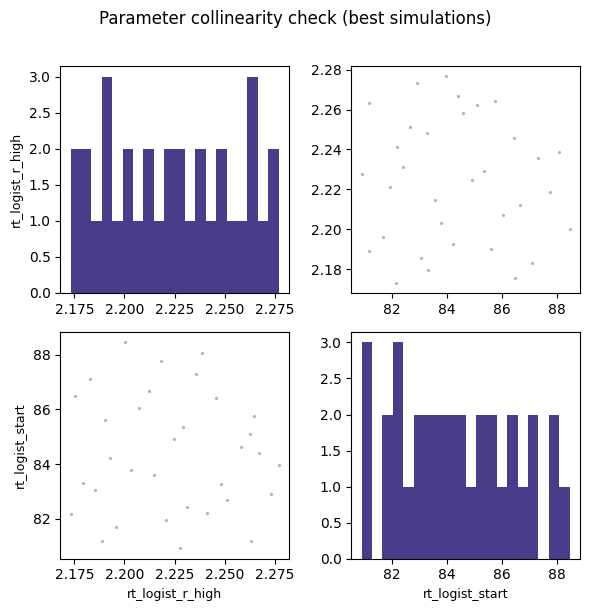

Average over selected parameter distributions: 
rt_logist_r_high     2.223650
rt_logist_start     84.384072
dtype: float64


In [4]:
# Colinearity plots (pairwise)
# ===============

with plt.rc_context():
    n_params = len(sampled_param_names)
    fig, axes = plt.subplots(
        nrows=n_params, ncols=n_params,
        figsize=(3 * n_params, 3 * n_params),
        squeeze=False,
    )

    for i, param_i in enumerate(sampled_param_names):
        for j, param_j in enumerate(sampled_param_names):
            ax: plt.Axes = axes[i, j]

            if i == j:
                # Diagonal: histogram
                ax.hist(best_sampled_params_df[param_i], bins=20, color="darkslateblue")
            else:
                # Off-diagonal: scatter
                ax.scatter(
                    best_sampled_params_df[param_j],
                    best_sampled_params_df[param_i],
                    s=2, alpha=0.3, color="darkslateblue", rasterized=True,
                )

            # Axis labels only on the outer edges
            if i == n_params - 1:
                ax.set_xlabel(param_j, fontsize=9)
            if j == 0:
                ax.set_ylabel(param_i, fontsize=9)

    fig.suptitle("Parameter collinearity check (best simulations)", y=1.01)
    plt.tight_layout()
    display(fig)

print(f"Average over selected parameter distributions: \n{best_sampled_params_df.mean(axis=0)}")

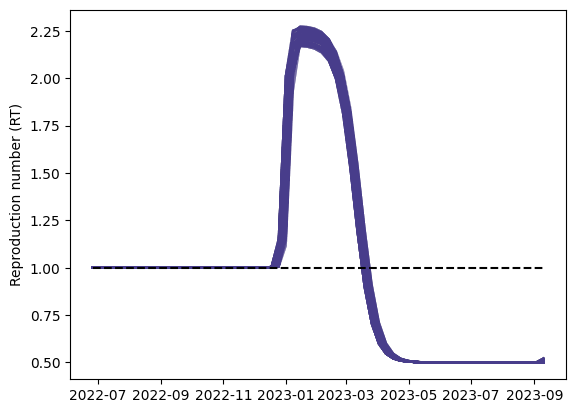

In [5]:
# Recreating RT curves of selected trajectories
# =================
# OBS: This cell is complex because it reproduces how RT is generated inside the simulator. If we extract that as a method, this could be simplified.

# Rebuild the full params df but only with the best sampled parameters
_config = deepcopy(config)
_n = best_sampled_params_df.shape[0]
_config.sampling.method = "given"
_params_df = build_calibration_params_df(_n, _config.sampling, given_params=best_sampled_params_df)
t_start = float((_config.temporal.sim_start - _config.temporal.zero_date).days) - simulator._gt_max_steps * _config.temporal.step_dt


rt_array = simulator.rt_model.generate(
    params_df=_params_df,
    num_time_steps=_config.num_time_steps,
    step_dt=_config.temporal.step_dt,
    t_start=t_start,
)

# Shift time to assign dates
_cols = _config.temporal.zero_date + pd.Timedelta(t_start, unit="D") + pd.to_timedelta(np.arange(rt_array.shape[1]) * _config.temporal.step_dt, unit="D")
rt_df = pd.DataFrame(
    rt_array,
    index=best_sampled_params_df.index,
    columns=_cols,
)

# -()- Optional: Random sample to reduce plot load
nsample = 500
df: pd.DataFrame = rt_df
df = df.sample(nsample, replace=True, random_state=42)
rt_df = df

# Summarize and visualize
# =======================


with plt.rc_context():
    fig, ax = plt.subplots()

    # Simulation medians
    df = rt_df
    ax.plot(df.T, color="darkslateblue", alpha=0.1)
    ax.plot(df.columns, np.ones(df.shape[1]), "k--")
    ax.set_ylabel("Reproduction number (RT)")

    display(fig)


In [11]:
from scipy.stats import pearsonr

pearsonr(
    best_sampled_params_df["rt_logist_start"],
    best_sampled_params_df["rt_logist_r_high"],
)

PearsonRResult(statistic=np.float64(-0.14204401903188285), pvalue=np.float64(3.86502198767223e-06))

## Exercise - Bayesian, likelihood, priors, etc

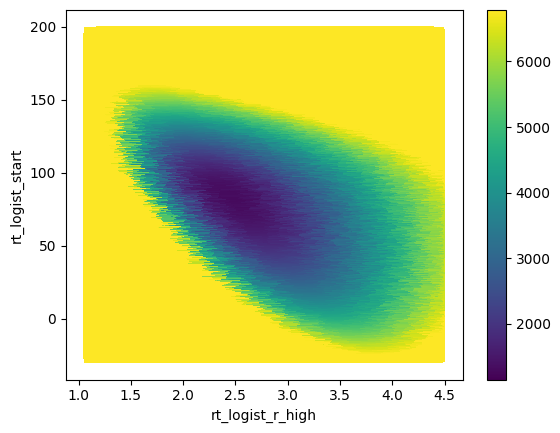

In [28]:
free_param_names = list(config.sampling.param_ranges.keys())

# Merge parameters and their scores
df = pd.merge(
    params_df, results.scoring.summary,
    left_index=True, right_index=True,
)

df

fig, ax = plt.subplots()


# Plot samples as is
import matplotlib.tri as tri
triangulation = tri.Triangulation(
    df[free_param_names[0]],
    df[free_param_names[1]],
)
plot = ax.tripcolor(
    triangulation, -df["nb_loglikelihood"],
    vmin=-df["nb_loglikelihood"].quantile(0.50), vmax=-df["nb_loglikelihood"].max()
)
ax.set_xlabel(free_param_names[0])
ax.set_ylabel(free_param_names[1])
fig.colorbar(plot)

fig